# pycorpdiff — the showcase

**Comparative corpus analysis for modern Python workflows.**

How does political discourse change? Whose words shape a movement? What did *immigrant* mean in 2005 versus 2023? Corpus linguistics, digital humanities, and computational social science answer questions like these — but the existing tooling is fragmented across `quanteda` (R), SketchEngine (closed-source), `nltk` / `spaCy` / `gensim` (Python NLP), and a half-dozen visualisation packages.

**`pycorpdiff` is the missing comparative layer.** Three verbs — `compare(a, b)`, `track(c, term)`, `compare.before_after(c, event)` — and one Protocol-based plugin model give you a coherent workflow from raw text to publication-grade figures, with every result carrying its own evidence.

This notebook drives **every analytical surface** in the package on a single research question: *how did UK parliamentary discourse on migration evolve across two decades?* Along the way we cross-validate against Scattertext on US convention speeches and HistWords on diachronic word embeddings — receipts you can take to a peer reviewer.

Bring coffee.

---

**What we'll cover:**

| Part | Theme | API |
|---|---|---|
| I | The corpus | `load_hansard_sample` · `Corpus.slice` |
| II | Lexical fingerprints | `compare(a, b).keyness()` + volcano / bar / explain |
| III | Collocational fingerprints | `.collocation_shift()` + diverging bar |
| IV | The temporal arc | `track().over_time()` · `.changepoints()` · `.interrupted_time_series()` |
| V | Beneath frequency | `.semantic_shift()` · `semantic_trajectory()` · `neighborhood_drift` |
| VI | The fanout | cross-party · cross-topic · `compare.before_after` |
| VII | Cross-validation | Scattertext · HistWords · Rayson reference values |
| VIII | The plumbing | polars · DuckDB · multilingual tokenizers |
| IX | Where next | follow-ups + real-world fetchers |

In [1]:
import warnings

import altair as alt
import numpy as np
import pandas as pd

import pycorpdiff as pcd

# Pre-render every chart to inline SVG via vl-convert so plots
# show up natively on GitHub, JupyterLab, VS Code, nbviewer, and
# the rendered HTML pipeline alike.
alt.renderers.enable('svg')
alt.data_transformers.disable_max_rows()

# Suppress fit-time convergence warnings (statsmodels, scipy);
# they include verbose interpreter paths that aren't worth
# carrying into the notebook output.
warnings.filterwarnings('ignore')
warnings.showwarning = lambda *a, **kw: None  # suppress any stragglers

# A consistent two-color palette: humanising in calm blue, criminalising in alert red.
HUMAN, CRIMINAL = '#2E86AB', '#E63946'

print(f'pycorpdiff {pcd.__version__}')

pycorpdiff 0.1.0a19


In [2]:
import pandas as pd  # noqa: F401  (already imported above; kept for the adapter)
from pysofra import SofraTable
from pysofra.core import Cell, HeaderCell, Row, HeaderRow


def df_to_sofra(df, *, theme='jama', caption=None, footnotes=()):
    cols = list(df.columns)
    headers = (HeaderRow(cells=tuple(HeaderCell(text=c) for c in cols)),)

    def fmt(col, val):
        try:
            if pd.isna(val):
                return 'n/a'
        except (ValueError, TypeError):
            return str(val)
        if 'p_' in col or col == 'p_value':
            return f'{val:.2e}' if val < 0.001 else f'{val:.3f}'
        if isinstance(val, float):
            if 'g2' in col or 'ratio' in col or 'effect' in col or 'change' in col:
                return f'{val:+.4f}' if abs(val) < 1 else f'{val:+.2f}'
            return f'{val:.4f}'
        return str(val)

    rows = tuple(
        Row(cells=tuple(Cell(text=fmt(c, row[c])) for c in cols))
        for _, row in df.iterrows()
    )
    return SofraTable(
        rows=rows, headers=headers,
        caption=caption, footnotes=footnotes, theme_name=theme,
    )

---

## Part I — The corpus

We start with the bundled `load_hansard_sample()` — a 193-speech synthetic corpus modelled on UK Hansard. Synthetic in the prose; real in the *structure*: nineteen years (2005–2023), four parties, four topics (immigration / Brexit / NHS / climate), and frame shifts at the right historical inflection points. Real Hansard from `parliament.uk` works through the same `Corpus` API; see Part VIII.

In [3]:
corpus = pcd.load_hansard_sample()
print(f'{len(corpus):,} speeches · {corpus.total_tokens():,} tokens · {len(corpus.docs.columns)} metadata columns')
corpus.docs.head(3)

193 speeches · 5,416 tokens · 7 metadata columns


,speech_id,text,topic,frame,party,date,year
0,0,"Mr Speaker, I wish to make a statement concern...",climate,scientific,Conservative,2005-08-15,2005
1,1,I beg leave to bring to the attention of this ...,climate,scientific,Labour,2005-01-05,2005
2,2,I am pleased to speak on the matter of brexit....,brexit,emerging,Liberal Democrat,2005-04-09,2005


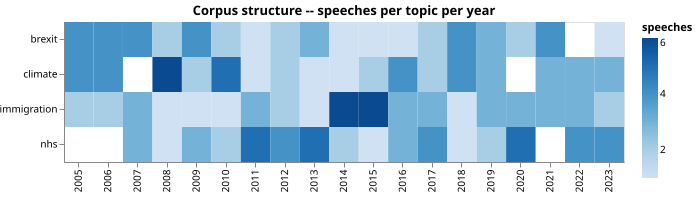

In [4]:
# A quick look at the structural skeleton: speeches per topic per year, coloured by frame.
skeleton = corpus.docs.groupby(['year', 'topic']).size().reset_index(name='n')
(
    alt.Chart(skeleton)
    .mark_rect()
    .encode(
        x=alt.X('year:O', title=None),
        y=alt.Y('topic:N', title=None),
        color=alt.Color('n:Q', scale=alt.Scale(scheme='blues'), title='speeches'),
        tooltip=['year', 'topic', 'n'],
    )
    .properties(width=560, height=140, title='Corpus structure -- speeches per topic per year')
)

---

## Part II — Lexical fingerprints

**Question:** *which words separate the humanising frame from the criminalising frame on immigration?*

`compare(a, b).keyness()` computes the signed Dunning log-likelihood (G²) for every shared-vocabulary term, plus Hardie's LogRatio effect size, Gabrielatos's %DIFF, the BIC-Bayes factor, Juilland's D and Gries's DP dispersion checks, and Benjamini–Hochberg multiple-comparison correction — all in one call.

In [5]:
immigration = corpus.slice(topic='immigration')
human = immigration.slice(frame='humanising')
criminal = immigration.slice(frame='criminalising')

print(f"humanising: {len(human)} speeches · {human.total_tokens()} tokens")
print(f"criminalising: {len(criminal)} speeches · {criminal.total_tokens()} tokens")

humanising: 28 speeches · 786 tokens
criminalising: 21 speeches · 582 tokens


In [6]:
keyness = pcd.compare(human, criminal).keyness(min_count=3, dispersion=True)
print(keyness.summary())
keyness.table.head(8)

df_to_sofra(
    keyness.table.head(8)[
        ['term', 'count_a', 'count_b', 'g2', 'log_ratio', 'p_value', 'p_adjusted']
    ],
    caption='Top 8 keyness terms — humanising vs criminalising frames',
    footnotes=('Signed Dunning G²; p-values BH-adjusted across the full vocabulary.',),
)


KeynessResult(log_likelihood, |a|=786, |b|=582, terms=119)


SofraTable(rows=8, cols=7, theme='jama')

**The volcano plot** — effect size on x, statistical significance on y. Each labelled term is a hypothesis.

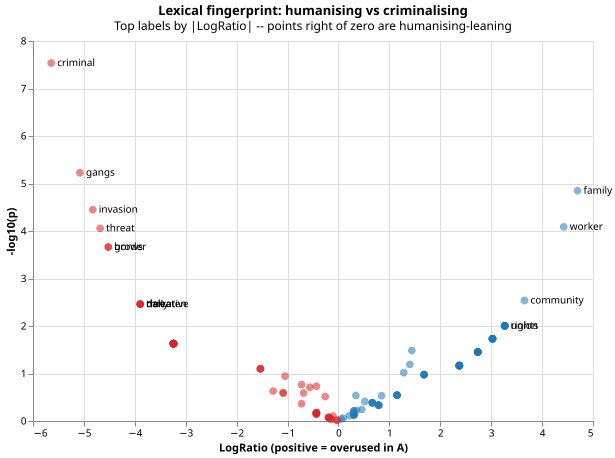

In [7]:
keyness.plot().properties(
    width=560, height=380,
    title=alt.TitleParams(
        text='Lexical fingerprint: humanising vs criminalising',
        subtitle='Top labels by |LogRatio| -- points right of zero are humanising-leaning',
    ),
)

**The bar chart** — same data, cleaner for a slide deck. Each Result has multiple visual modes.

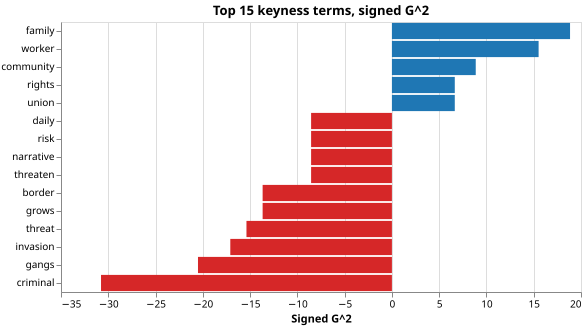

In [8]:
keyness.plot(kind='bar', n=15).properties(
    width=520, title='Top 15 keyness terms, signed G^2'
)

**The Scattertext-style plot** — Kessler 2017's signature interactive scatter, surfaced as `keyness.plot(kind='scattertext')`. Each term sits at *(rank-percentile in A, rank-percentile in B)*; the dashed diagonal is the *equally-distinctive* line; off-diagonal points are the words that pry the two frames apart. Pan/zoom is live; hover for the full row.

Stopwords cluster in the top-right; humanising-distinctive terms fall into the lower-right zone (blue); criminalising-distinctive terms into the upper-left zone (red). One picture, every keyword.

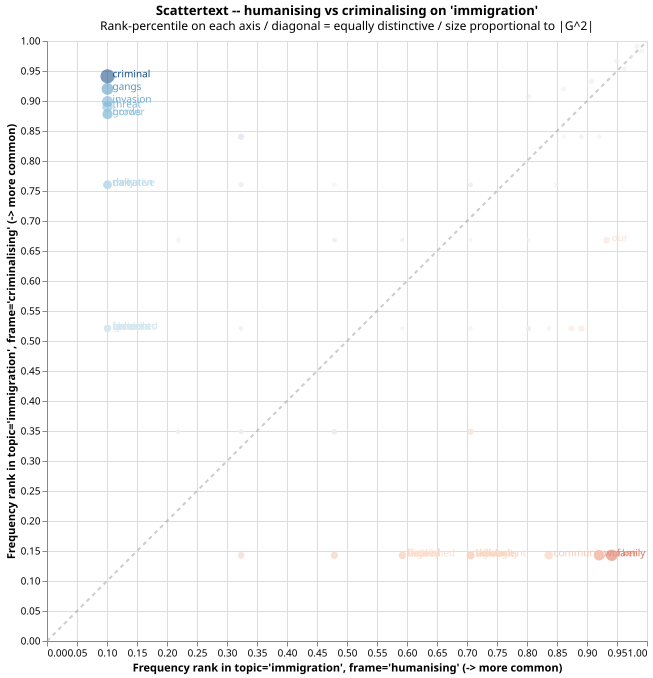

In [9]:
keyness.plot(kind='scattertext', n_labels=18).properties(
    width=600, height=600,
    title=alt.TitleParams(
        text="Scattertext -- humanising vs criminalising on 'immigration'",
        subtitle='Rank-percentile on each axis / diagonal = equally distinctive / size proportional to |G^2|',
    ),
)

**Where in the corpus does it actually appear?** Frequency tells you *how often*; dispersion tells you *how spread out*. `pcd.viz.dispersion_plot` is the Mosteller-style tick chart that turns each occurrence of a target into a mark on the document timeline. Bursty terms cluster; ubiquitous terms spread evenly.

Here we contrast a humanising-leaning keyword and a criminalising-leaning keyword across the immigration sub-corpus.

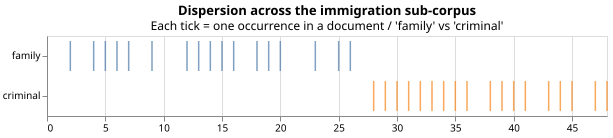

In [10]:
from pycorpdiff.viz import dispersion_plot

# Pick one distinctive term from each side of the keyness ranking.
top_human = keyness.table[keyness.table['g2'] > 0]['term'].iloc[0]
top_criminal = keyness.table[keyness.table['g2'] < 0]['term'].iloc[0]

dispersion_plot(immigration, [top_human, top_criminal]).properties(
    width=560,
    title=alt.TitleParams(
        text='Dispersion across the immigration sub-corpus',
        subtitle=f'Each tick = one occurrence in a document / {top_human!r} vs {top_criminal!r}',
    ),
)

**Two knobs worth knowing.** Same machinery, two power-user toggles:

- `stop_words=` filters function words *after* the totals are computed, so the rate denominators stay honest.
- `method='chi_squared'` swaps in Pearson χ² instead of G². They're asymptotically equivalent; χ² is the form quanteda and SketchEngine often report.

In [11]:
STOPWORDS = {'the', 'of', 'and', 'to', 'a', 'in', 'that', 'is', 'it'}

filtered = pcd.compare(human, criminal).keyness(
    min_count=3, stop_words=STOPWORDS, method='chi_squared',
)
print(filtered.summary())
df_to_sofra(
    filtered.table[['term', 'count_a', 'count_b', 'g2', 'chi_squared', 'log_ratio']].head(8),
    caption='Top 8 keyness terms — Pearson χ² method, function-word stop-list applied',
    footnotes=('Same machinery as the default G²; χ² as the sort statistic.',),
)

KeynessResult(chi_squared, |a|=786, |b|=582, terms=114)


SofraTable(rows=8, cols=6, theme='jama')

**Permutation *p*-values — when the χ² approximation is suspect.** Dunning's 1993 paper warned that the asymptotic *p*-values from G² lose calibration when expected cell counts get small — exactly where rare keywords spend most of their time. The robust answer is a permutation test: build the null distribution empirically by shuffling document labels and recomputing G² each pass.

`permutation_n=999` adds an empirical *p*-value to every row. Computationally heavier than the asymptotic χ², so it's opt-in — but for paper-grade work on small or zero-cell-heavy data, it's the gold standard. The Phipson–Smyth (2010) +1/+1 correction means the smallest reportable *p* is `1/(B+1)`, not 0.

In [12]:
keyness_perm = pcd.compare(human, criminal).keyness(
    min_count=3, permutation_n=999, permutation_seed=42,
)
(
    keyness_perm.table
    [['term', 'count_a', 'count_b', 'g2', 'p_value', 'p_permutation']]
    .head(10)
    .assign(
        p_value=lambda d: d['p_value'].map(lambda p: f'{p:.2e}'),
        p_permutation=lambda d: d['p_permutation'].map(lambda p: f'{p:.4f}'),
    )
)
df_to_sofra(
    keyness_perm.table
    [['term', 'count_a', 'count_b', 'g2', 'p_value', 'p_permutation']]
    .head(10),
    caption='Asymptotic χ² vs empirical permutation p-values (B = 999)',
    footnotes=('Phipson–Smyth +1/+1 correction; permutation floor = 1/1000 = 0.001.',),
)


term,count_a,count_b,g2,p_value,p_permutation
criminal,0,18,-30.77,2.91e-08,0.001
gangs,0,12,-20.51,5.93e-06,0.001
family,17,0,+18.84,1.42e-05,0.001
invasion,0,10,-17.09,3.56e-05,0.001
worker,14,0,+15.52,8.18e-05,0.001
threat,0,9,-15.38,8.78e-05,0.001
border,0,8,-13.67,2.17e-04,0.001
grows,0,8,-13.67,2.17e-04,0.001
community,8,0,+8.87,0.003,0.004
daily,0,5,-8.55,0.003,0.001


Both columns agree on which terms matter — every strong asymptotic signal also hits the permutation floor (`1/1000 = 0.001`). The value of the permutation column is in the *other* direction: it caps how confident you can be about a finding given finite resampling, and it stays well-behaved where the χ² approximation starts drifting. Plot the two against each other to see the relationship at a glance.

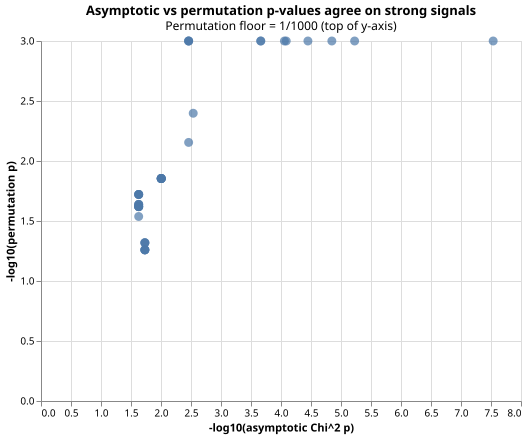

In [13]:
import numpy as np

pp = keyness_perm.table.copy()
pp['neg_log_p_chi2'] = -np.log10(np.clip(pp['p_value'], 1e-300, 1.0))
pp['neg_log_p_perm'] = -np.log10(np.clip(pp['p_permutation'], 1e-300, 1.0))

(
    alt.Chart(pp.head(40))
    .mark_circle(opacity=0.7, size=80)
    .encode(
        x=alt.X('neg_log_p_chi2:Q', title='-log10(asymptotic Chi^2 p)'),
        y=alt.Y('neg_log_p_perm:Q', title='-log10(permutation p)'),
        tooltip=['term', 'count_a', 'count_b', 'g2',
                 alt.Tooltip('p_value:Q', format='.2e'),
                 alt.Tooltip('p_permutation:Q', format='.4f')],
    )
    .properties(
        width=480, height=360,
        title=alt.TitleParams(
            text='Asymptotic vs permutation p-values agree on strong signals',
            subtitle='Permutation floor = 1/1000 (top of y-axis)',
        ),
    )
)

**Bootstrap confidence intervals on G² — direction-of-effect honesty.**
A G² point estimate is computed from a *sample* of speeches; the
underlying population ("the kind of debate the corpus represents")
has its own variability. `ci="bootstrap"` resamples documents
with replacement on each side and reports the empirical 2.5 / 97.5
percentiles of the per-term G². When the CI straddles zero, we
have a useful signal: the direction of over-use isn't certain.
Documents (not tokens) are the unit of resampling, matching the
population-level inference researchers actually want.

In [14]:
keyness_boot = pcd.compare(human, criminal).keyness(
    min_count=3, ci='bootstrap', n_boot=399, bootstrap_seed=0
)
cols = ['term', 'count_a', 'count_b', 'g2', 'g2_ci_lower', 'g2_ci_upper']
keyness_boot.table[cols].head(10)


,term,count_a,count_b,g2,g2_ci_lower,g2_ci_upper
0,criminal,0,18,-30.766847,-36.175444,-23.750783
1,gangs,0,12,-20.511232,-27.994110,-13.493554
2,family,17,0,18.841042,12.826844,23.776690
3,invasion,0,10,-17.092693,-25.331147,-8.324213
4,worker,14,0,15.516153,9.909531,21.161308
5,threat,0,9,-15.383424,-23.626732,-8.395639
6,border,0,8,-13.674154,-21.829708,-6.798157
7,grows,0,8,-13.674154,-21.017357,-7.085041
8,community,8,0,8.866373,4.230722,14.449487
9,daily,0,5,-8.546347,-15.380653,-1.783119


**Reference-corpus keyness — `against_baseline`.**
The canonical setup in lexicography and discourse analysis: compare
the corpus against a *fixed reference* (BNC, COCA, an in-house
archive, …) rather than another corpus on hand. The reference side
ships as an aggregated `(term, count)` frequency list — typically
two to three orders of magnitude smaller than the source text.
pycorpdiff bundles one starter: `"gutenberg_fiction"` (five
Project Gutenberg English-fiction texts, 1813–1897, ~500K tokens).
User-built baselines come from `pcd.baseline_from_corpus(corpus)`.

In [15]:
baseline_result = pcd.against_baseline(
    corpus, 'gutenberg_fiction', min_count=10
)
print(baseline_result.summary())
baseline_result.table[['term', 'count_a', 'count_b', 'g2', 'log_ratio']].head(10)


KeynessResult(log_likelihood, |a|=5,416, |b|=502,234, terms=3,695)


,term,count_a,count_b,g2,log_ratio
0,climate,122,3,1079.624797,11.664271
1,nhs,102,0,926.248678,14.214468
2,immigrant,78,0,708.307813,13.829609
3,brexit,64,0,581.175641,13.546215
4,speaker,57,2,500.183475,11.058550
5,house,114,423,489.061537,4.647974
6,immigration,49,0,444.962600,13.164345
7,address,59,55,379.053986,6.635390
8,honourable,48,12,376.090866,8.491045
9,this,167,2118,366.668273,2.874178


**Every result carries its evidence.** `.explain(term)` pulls KWIC concordances from both sides — no black boxes.

In [16]:
top_term = keyness.table.iloc[0]['term']
print(f'Showing KWIC contexts for the top keyword: {top_term!r}\n')
keyness.explain(top_term, n=3, window=4).table

Showing KWIC contexts for the top keyword: 'criminal'



,corpus,doc_id,position,left,keyword,right
0,"topic='immigration', frame='criminalising'",0,17,border and the immigrant,criminal,risk grows daily i
1,"topic='immigration', frame='criminalising'",1,11,consider immigration the immigrant,criminal,threat grows and the
2,"topic='immigration', frame='criminalising'",2,18,border and the immigrant,criminal,risk grows daily i


**Lexical diversity — how varied is the vocabulary?**
Keyness asks *which* words separate the corpora; lexical
diversity asks how varied each one is internally. Type-token
ratio is the naive measure but it's confounded with text
length, so we ship three length-robust alternatives: MATTR
(moving-average TTR, Covington & McFall 2010), MTLD (mean
factor length to a running-TTR threshold, McCarthy & Jarvis
2010), and HD-D (hypergeometric expected vocabulary in a
42-token sample, McCarthy & Jarvis 2007). Pooled corpus-level:

In [17]:
ld_human = pcd.lexical_diversity(human)
ld_criminal = pcd.lexical_diversity(criminal)
print(ld_human.summary())
print(ld_criminal.summary())


LexicalDiversityResult(label="topic='immigration', frame='humanising'", |tokens|=786, |types|=107, TTR=0.136, MATTR=0.517, MTLD=45.5, HD-D=29.57)
LexicalDiversityResult(label="topic='immigration', frame='criminalising'", |tokens|=582, |types|=94, TTR=0.162, MATTR=0.512, MTLD=41.5, HD-D=27.80)


**The temporal arc.** `freq='Y'` slices by year and reports
per-period metrics; `ci='bootstrap'` adds document-resampled
uncertainty bands. The plot facets one panel per metric so
the very different scales (TTR ~ 0.5, MTLD ~ 50–100, HD-D
~ 30) stay legible side-by-side. The Hansard sample is small
per-year so the bands are wide — real archives produce much
tighter trajectories.

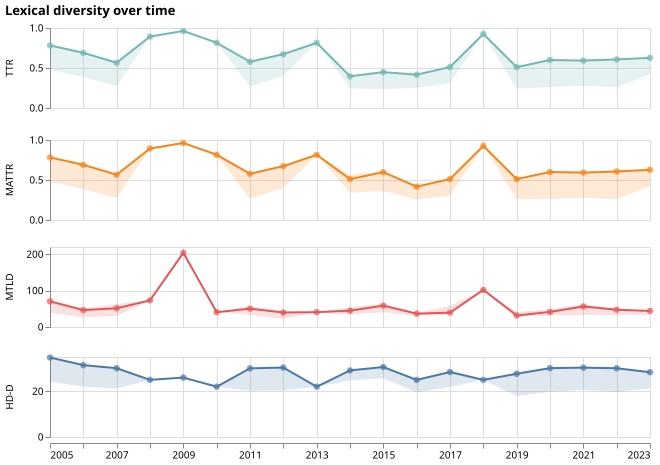

In [18]:
ld_traj = pcd.lexical_diversity(
    immigration, freq='Y', time_col='date',
    ci='bootstrap', n_boot=99, seed=0,
)
ld_traj.plot()


**Size-fair diversity — Hill numbers + rarefaction.** Raw richness is confounded with corpus size: a larger slice looks more varied simply because more tokens were drawn. `hill_numbers` puts richness (`q=0`), exp-Shannon (`q=1`), and inverse-Simpson (`q=2`) on one effective-number-of-types scale; `rarefaction` reports expected richness at a common sample size. Both take an abundance vector — `slice.vocab()` returns one. Here the humanising frame is richer (107 vs 94 types) and *stays* ahead after rarefying to the common size (104.7 vs 94) — a genuinely more varied vocabulary, not just more words.

In [59]:
from pycorpdiff.lexical import hill_numbers, rarefaction

vh, vc = human.vocab().values, criminal.vocab().values
n = min(int(vh.sum()), int(vc.sum()))
pd.DataFrame({
    'frame': ['humanising', 'criminalising'],
    'tokens': [int(vh.sum()), int(vc.sum())],
    'richness q0': [hill_numbers(vh, 0), hill_numbers(vc, 0)],
    'expShannon q1': [round(hill_numbers(vh, 1), 1), round(hill_numbers(vc, 1), 1)],
    'invSimpson q2': [round(hill_numbers(vh, 2), 1), round(hill_numbers(vc, 2), 1)],
    f'rarefied richness @ {n}': [round(rarefaction(vh, n), 1), round(rarefaction(vc, n), 1)],
})

,frame,tokens,richness q0,expShannon q1,invSimpson q2,rarefied richness @ 582
0,humanising,786,107.0,66.4,39.1,104.7
1,criminalising,582,94.0,53.9,31.6,94.0


**Pre-balancing via Coarsened Exact Matching.**
The keyness above is honest about *what* separates the two frames
lexically, but doesn't tell us whether the lexical difference
rides on a *confounding* difference in year × party composition
between the two slices. `pcd.match` runs CEM (Iacus, King & Porro
2012): coarsen each covariate (year → quantile bins, party →
as-is), match strata across sides, drop unmatched strata, and
subsample the over-represented side per stratum. The result is
matched slices balanced on the chosen covariates — and a
before-vs-after L1-imbalance diagnostic showing how much
confounding the match removed.

In [19]:
matched = pcd.match(human, criminal, on=['year', 'party'], seed=0)
print(matched.summary())
matched.imbalance


CEM match on ['year', 'party']: 2/16 strata matched, |a|: 28 → 2 (7%), |b|: 21 → 2 (10%). Mean L1 imbalance: 0.548 → 0.000.


,l1_pre,l1_post
covariate,,
year,0.857143,0.0
party,0.238095,0.0


Matched keyness re-runs the same scoring on the balanced
subsample. Terms that survive *here* are the lexical signal
after the demographic confounders are stripped out.

In [20]:
keyness_matched = pcd.compare(matched.a_matched, matched.b_matched).keyness(min_count=1)
keyness_matched.table[['term', 'count_a', 'count_b', 'g2', 'log_ratio']].head(10)


,term,count_a,count_b,g2,log_ratio
0,motion,0,2,-2.910533,-2.419775
1,commend,0,2,-2.910533,-2.419775
2,grows,0,2,-2.910533,-2.419775
3,gangs,0,2,-2.910533,-2.419775
4,risk,0,2,-2.910533,-2.419775
5,threaten,0,2,-2.910533,-2.419775
6,border,0,2,-2.910533,-2.419775
7,daily,0,2,-2.910533,-2.419775
8,criminal,0,2,-2.910533,-2.419775
9,members,0,1,-1.455267,-1.682810


---

## Part III — Collocational fingerprints

**Question:** *what does each frame put next to the word 'immigrant'?* This is where Hardie's logDice and SketchEngine's word-sketch tradition shine — the company a word keeps says more than its frequency.

`collocation_shift` computes window-based co-occurrences in each corpus, applies Laplace smoothing so absent collocates yield finite scores, and reports the per-collocate delta `score_a − score_b`.

In [21]:
shift = pcd.compare(human, criminal).collocation_shift(
    'immigrant', window=4, min_count=3, measure='logDice'
)
print(shift.summary())
df_to_sofra(
    shift.table.head(10),
    caption="Top 10 collocate shifts of 'immigrant' — logDice, window 4",
    footnotes=('Score_a − score_b; Laplace smoothing α = 0.5.',),
)

CollocationShiftResult(target='immigrant', measure=logDice, window=4, collocates=63)


collocate,count_a,count_b,score_a,score_b,shift
criminal,0,18,8.6781,13.3515,-4.6734
family,17,0,13.2964,8.6781,4.6183
gangs,0,14,8.6781,13.1575,-4.4795
worker,14,0,13.1031,8.6781,4.4250
threat,0,12,8.6781,13.0291,-4.3511
grows,0,11,8.6781,12.9386,-4.2605
hope,10,0,12.9005,8.6781,4.2224
thrived,10,0,12.9005,8.6781,4.2224
border,0,10,8.6781,12.8074,-4.1293
invasion,0,10,8.6781,12.7485,-4.0704


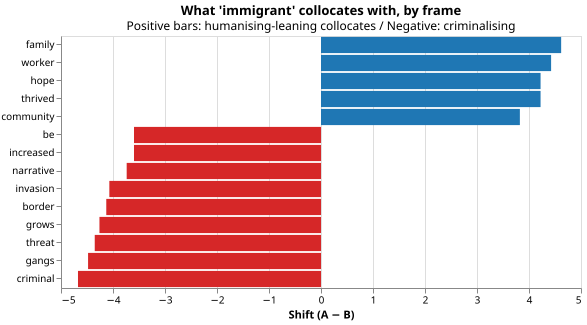

In [22]:
shift.plot(n=14).properties(
    width=520,
    title=alt.TitleParams(
        text="What 'immigrant' collocates with, by frame",
        subtitle='Positive bars: humanising-leaning collocates / Negative: criminalising',
    ),
)

`.explain(collocate)` here is sharper than for keyness: it returns *only* the KWIC windows in which both 'immigrant' AND the collocate co-occur — the actual textual evidence for the shift.

In [23]:
shift.explain('criminal', n=3).table

,corpus,doc_id,position,left,keyword,right
0,"topic='immigration', frame='criminalising'",0,16,the border and the,immigrant,criminal risk grows daily
1,"topic='immigration', frame='criminalising'",1,10,should consider immigration the,immigrant,criminal threat grows and
2,"topic='immigration', frame='criminalising'",2,17,the border and the,immigrant,criminal risk grows daily


**Bigrams and trigrams as first-class terms.** `NgramTokenizer` wraps any base tokenizer and emits joined n-grams (`'border_security'`, `'asylum_seeker'`). Because the output is still `list[str]`, every analytical surface — keyness, collocations, semantic shift — picks up multi-word units with no special-casing.

Useful when the discriminating *unit* is a phrase, not a word.

In [24]:
from pycorpdiff.tokenize import NgramTokenizer

bigram_tok = NgramTokenizer(n=2)
human_bg = human.parent.with_tokenizer(bigram_tok).slice(frame='humanising', topic='immigration')
criminal_bg = criminal.parent.with_tokenizer(bigram_tok).slice(frame='criminalising', topic='immigration')

bigram_keyness = pcd.compare(human_bg, criminal_bg).keyness(min_count=2)
print(f'{len(bigram_keyness.table):,} bigram terms ranked')
bigram_keyness.table[['term', 'count_a', 'count_b', 'g2', 'log_ratio']].head(10)

210 bigram terms ranked


,term,count_a,count_b,g2,log_ratio
0,immigrant_criminal,0,18,-30.776697,-5.643650
1,immigrant_family,17,0,18.834156,4.695086
2,immigrant_invasion,0,10,-17.098165,-4.826515
3,immigrant_worker,14,0,15.510481,4.423784
4,criminal_threat,0,6,-10.258899,-4.134637
5,immigrant_community,8,0,8.863132,3.653266
6,border_and,0,5,-8.549082,-3.893629
7,gangs_threaten,0,5,-8.549082,-3.893629
8,grows_daily,0,5,-8.549082,-3.893629
9,immigrant_gangs,0,5,-8.549082,-3.893629


### The discourse graph — every term as a node

**Question:** *what does the discourse look like as a graph?* Collocation shift answers "which collocates of X moved". The complementary view is to step back and let every term be a node, every co-occurrence be an edge, and read off the cluster structure of the discourse itself.

`pcd.cooccurrence_network(corpus, ...)` builds the network: top-N frequent terms as nodes, edges weighted by PMI (or t-score / MI³ / logDice) within a context window. The `.plot()` lays it out via `networkx.spring_layout` and renders with altair — pan/zoom, hover tooltips, the works.

In [25]:
net = pcd.cooccurrence_network(
    immigration, top_n=18, window=5, measure='PMI',
    min_count=4, min_cooccur=5,
)
print(net.summary())

NetworkResult(measure=PMI, window=5, nodes=18, edges=79)


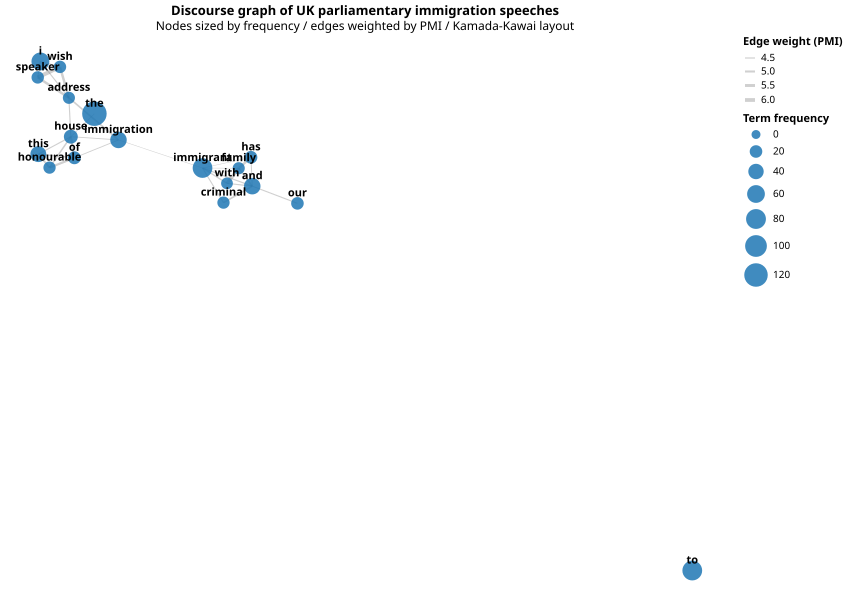

In [26]:
net.plot(width=720, height=560, max_edges=30, label_top_n=18).properties(
    title=alt.TitleParams(
        text='Discourse graph of UK parliamentary immigration speeches',
        subtitle='Nodes sized by frequency / edges weighted by PMI / Kamada-Kawai layout',
    ),
)

The graph's structure carries information the bar charts can't. Tight clusters of mutually-collocating terms read as recurring discursive phrases; bridges between clusters mark the words that move *between* frames; isolated nodes are vocabulary peripherally invoked but not syntactically interlocked. Hover any edge for the raw joint count and PMI weight.

---

## Part IV — The temporal arc

**Question:** *when did the frame shift happen?* Frequency analysis becomes a time-series problem the moment you have dated documents.

`track(corpus, term).over_time()` returns a tidy DataFrame with per-period relative frequencies and Wilson score confidence intervals (Wilson > Wald because Wald collapses near p = 0 — exactly where rare-term trajectories spend most of their time).

In [27]:
trajectory = pcd.track(immigration, ['worker', 'criminal', 'family']).over_time(
    freq='Y', time_col='date'
)
trajectory.summary()

"TemporalTrajectory(targets=['worker', 'criminal', 'family'], freq='Y', periods=19)"

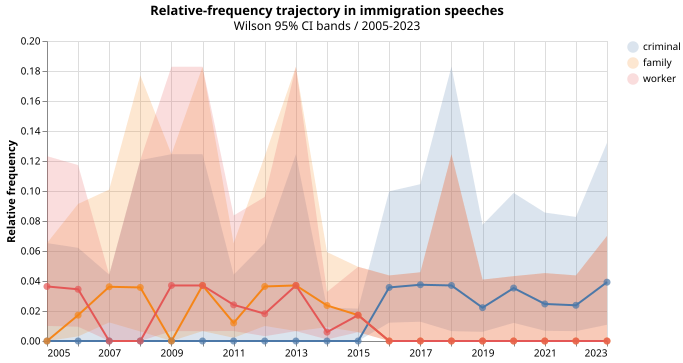

In [28]:
trajectory.plot().properties(
    width=560, height=300,
    title=alt.TitleParams(
        text='Relative-frequency trajectory in immigration speeches',
        subtitle='Wilson 95% CI bands / 2005-2023',
    ),
)

**Changepoint detection** — PELT, wrapped from `ruptures`. The break should land near 2016, the engineered policy event in the synthetic corpus.

In [29]:
trajectory.changepoints(target='criminal')

,period,index,method
0,2015,10,pelt


**Burstiness — "when was the rate elevated?" per period.**
Where `changepoints()` answers *when did the rate change?*
(segmentation by location), Kleinberg's 1999 algorithm answers
*when was the rate elevated and by how much?* (per-period
intensity labelling). State 0 is the base rate; state 1, 2, …
are progressively stronger bursts. Bursting up is costly,
bursting down is free.

In [30]:
bursts = trajectory.burstiness(target='criminal', s=2.0, gamma=1.0)
print(bursts.summary())
bursts.bursts


BurstinessResult(target='criminal', 1 burst(s), max intensity = state 1, base rate p_0 = 1.32e-02)


,start,end,n_periods,max_state,total_count,mean_relfreq
0,2016,2023,8,1,18,0.031936


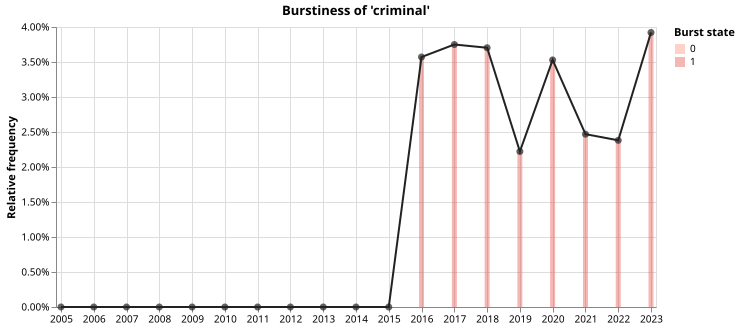

In [31]:
bursts.plot()


**Interrupted time series** — segmented regression via `statsmodels.OLS`. Quantifies the level change at a known event with confidence intervals.

*Reading the row labels:* `intercept` = pre-event baseline · `time` = pre-event trend · **`level_change` = the step at the event** · **`slope_change` = post-event trend change**.

> **Caveat on the synthetic demo.** The bundled Hansard-style sample is deterministic — the engineered relative frequencies for `"criminal"` in the pre-event window have very low variance, so OLS standard errors below are at floating-point precision and the *p*-values are astronomically small. On real data with realistic noise these numbers will be normal-looking. Treat the ITS output here as a syntactic demonstration of the API, not a statistical worked example.

In [32]:
df_to_sofra(
    trajectory.interrupted_time_series(event_date='2016', target='criminal'),
    caption="Interrupted time-series coefficients for 'criminal', 2016 event",
    footnotes=('Segmented OLS (Wagner et al. 2002). level_change = step at the event; '
               'slope_change = post-event trend deviation.',),
)

SofraTable(rows=4, cols=7, theme='jama')

**Where is the trajectory heading?** Past `interrupted_time_series` the question stops being retrospective. The modern temporal stack — *forecast*, *counterfactual*, *online detection* — lets the same trajectory answer three predictive questions in turn.

First: **`.forecast()`** extends the line forward with state-space exponential smoothing (Hyndman et al. 2008). Rates are forecast on the logit scale and back-transformed so prediction intervals stay pinned to `[0, 1]` instead of leaking into negative territory. Auto-selects ETS for series of length ≥ 8, falls back to a Holt linear-trend for shorter histories.

ForecastResult(targets=['worker', 'criminal', 'family'], freq='Y', horizon=4, level=0.95, method=auto)


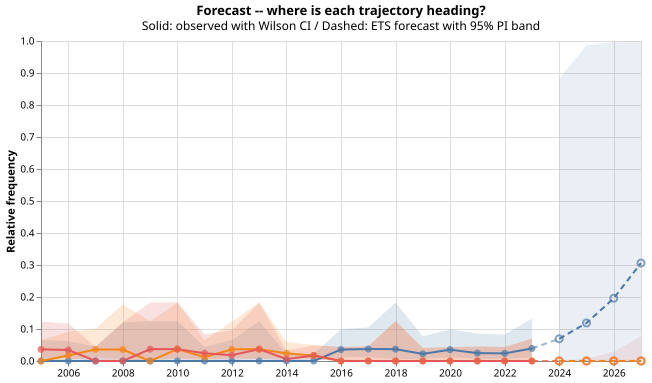

In [33]:
fc = trajectory.forecast(horizon=4, level=0.95)
print(fc.summary())
fc.plot().properties(
    width=600, height=320,
    title=alt.TitleParams(
        text='Forecast -- where is each trajectory heading?',
        subtitle='Solid: observed with Wilson CI / Dashed: ETS forecast with 95% PI band',
    ),
)

**Counterfactual causal impact** is the headline addition. `interrupted_time_series` answers "is there a step at this known event?". The harder — and more useful — question is the counterfactual: *what would the trajectory have looked like* without *the event?* `.causal_impact()` wraps a Bayesian structural time-series model (Brodersen et al. 2015) — fits on the pre-event window, projects forward as the counterfactual, and reports the pointwise and cumulative effects with credible intervals from Monte Carlo against the joint posterior.

The three-panel chart below is recognisable from the CausalImpact literature: observed-vs-counterfactual, pointwise effect, cumulative effect. Each band is a 95% credible interval; the vertical dashed line marks the event.

In [34]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    impact = trajectory.causal_impact(
        event_date='2016', target='criminal',
        n_samples=1000, seed=42,
    )
print(impact.summary())

# Brodersen-style metrics as a publication table.
_metrics_df = pd.DataFrame([
    {'metric': 'avg effect per period',
     'estimate': impact.metrics['avg_effect'],
     'ci_lower': impact.metrics['avg_effect_lower'],
     'ci_upper': impact.metrics['avg_effect_upper']},
    {'metric': 'cumulative effect',
     'estimate': impact.metrics['cumulative_effect'],
     'ci_lower': impact.metrics['cumulative_effect_lower'],
     'ci_upper': impact.metrics['cumulative_effect_upper']},
    {'metric': 'posterior P(no effect)',
     'estimate': impact.metrics['posterior_prob_no_effect'],
     'ci_lower': float('nan'), 'ci_upper': float('nan')},
])
df_to_sofra(
    _metrics_df,
    caption='Brodersen-style causal impact metrics for the 2016 event',
    footnotes=('95% credible intervals via Monte Carlo against the joint state-space posterior; '
               'n_samples=1000, seed=42.',),
)

CausalImpactResult(target='criminal', event=2016-01-01, pre=11, post=8)
  avg effect:        +0.0319 per period  (95% CrI [+0.0318, +0.0321])
  cumulative effect: +0.2554
  relative effect:   n/a (counterfactual ≈ 0) vs counterfactual mean
  P(no effect):      0.000


SofraTable(rows=3, cols=4, theme='jama')

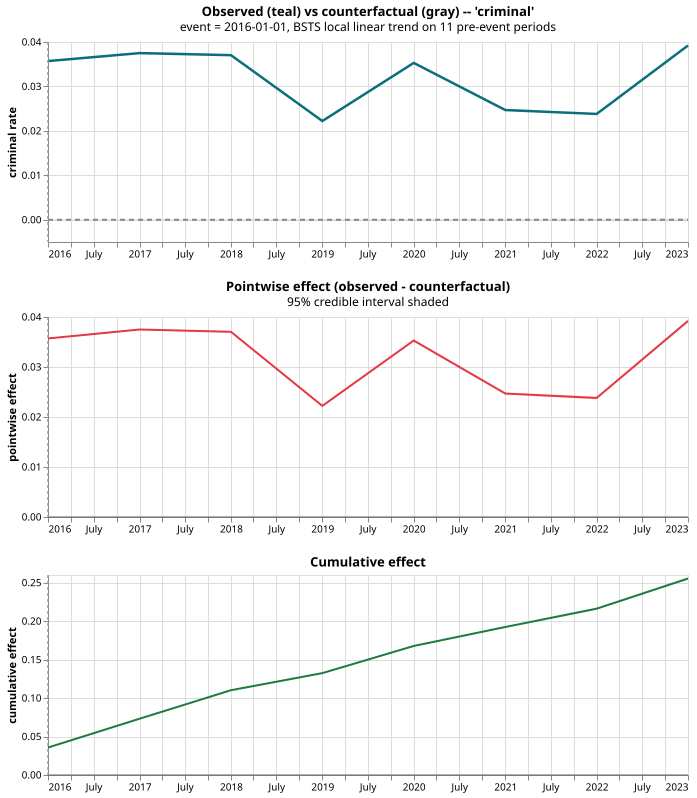

In [35]:
impact.plot()

**Bayesian online changepoint detection** — `.changepoints()` is offline PELT: needs the full series, returns MAP locations after the fact. `.changepoints_online()` does Adams & MacKay's (2007) Bayesian forward pass: at each new period it updates the posterior distribution over the *run length* (number of periods since the last changepoint). The MAP run length collapsing to a small number marks a changepoint; the recovery growth tells you the new regime has stabilised. Useful when you're rolling a corpus forward in time and want a 'did things just shift?' signal each period.

The diagnostic plot has three panels: the observed series with detected changepoints flagged, a log-scale heatmap of the run-length posterior, and the MAP run length over time.

In [36]:
online = trajectory.changepoints_online(
    target='criminal', hazard=0.02,
    mu_0=0.0, beta_0=0.0001,
)
print(online.summary())
online.detected_changepoints(threshold=3)

BocpdResult(hazard=0.02, T=19, detected=6)


,period,value,map_run_length,cp_probability
0,2005,0.000000,1,0.02
1,2006,0.000000,2,0.02
2,2007,0.000000,3,0.02
3,2016,0.035714,1,0.02
4,2017,0.037500,2,0.02
5,2018,0.037037,3,0.02


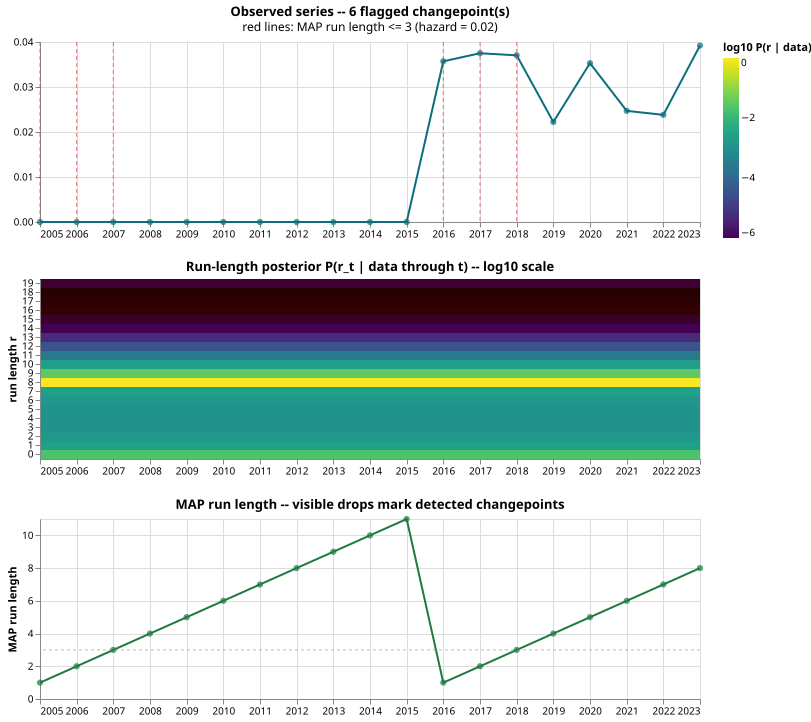

In [37]:
online.plot()

---

## Part V — Beneath frequency: semantic shift

Frequencies and collocations measure *which words appear together*. **Semantic shift** measures whether the same word *means* something different now.

`compare(a, b).semantic_shift(target, embedder)` encodes every KWIC window around the target as a sentence vector and averages into a corpus-specific centroid. Cosine distance between the centroids is the reported shift. With SBERT it captures real meaning drift; with the deterministic `HashEmbedder` it gives a byte-stable demonstration of the pipeline.

In [38]:
# Note: HashEmbedder is for demo / test reproducibility. In real research,
# swap in `pcd.SBERTEmbedder()` — needs `pip install 'pycorpdiff[semantic]'`.
sem = pcd.compare(human, criminal).semantic_shift(
    'immigrant', embedder=pcd.HashEmbedder(dim=64), window=4
)
sem.table

,target,cosine_similarity,cosine_distance,n_contexts_a,n_contexts_b
0,immigrant,-0.112425,1.112425,39,39


**Multi-period semantic trajectory** — for tracking semantic drift *over time* rather than between two corpora. Built on the same averaged-contextual-embedding machinery.

In [39]:
sem_traj = pcd.semantic_trajectory(
    immigration,
    'immigrant',
    time_col='date', freq='Y',
    embedder=pcd.HashEmbedder(dim=64), window=4,
)
sem_traj

,period,target,n_contexts,similarity_to_baseline,distance_from_baseline
0,2005,immigrant,2,1.000000,0.000000
1,2006,immigrant,3,-0.026654,1.026654
2,2007,immigrant,4,-0.074471,1.074471
3,2008,immigrant,2,0.001824,0.998176
4,2009,immigrant,1,-0.015105,1.015105
5,2010,immigrant,2,-0.149172,1.149172
6,2011,immigrant,5,0.123733,0.876267
7,2012,immigrant,4,0.109167,0.890833
8,2013,immigrant,2,-0.149172,1.149172
9,2014,immigrant,8,0.168964,0.831036


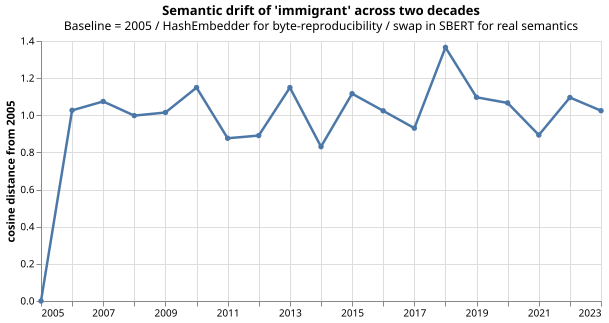

In [40]:
plot_df = sem_traj.assign(
    period_str=sem_traj['period'].astype(str),
    period_ts=sem_traj['period'].apply(lambda p: p.to_timestamp()),
).drop(columns='period')

(
    alt.Chart(plot_df)
    .mark_line(point=True, strokeWidth=2.5)
    .encode(
        x=alt.X('period_ts:T', title=None),
        y=alt.Y('distance_from_baseline:Q', title='cosine distance from 2005'),
        tooltip=['period_str', 'n_contexts', 'distance_from_baseline'],
    )
    .properties(
        width=560, height=260,
        title=alt.TitleParams(
            text="Semantic drift of 'immigrant' across two decades",
            subtitle='Baseline = 2005 / HashEmbedder for byte-reproducibility / swap in SBERT for real semantics',
        ),
    )
)

**Where is meaning *heading*?** `pcd.forecast_semantic_drift` does for semantic drift what `.forecast()` does for rates — extends the cosine-displacement trajectory forward with the same state-space machinery. The logit transform is off (cosine distance lives in roughly `[0, 2]`, not `[0, 1]`) and the lower prediction-interval bound is clipped at zero since negative cosine distance is nonsensical.

Useful for asking *is the drift accelerating or stabilising?*

  period     target     point  ci_lower  ci_upper
0   2024  immigrant  1.166032  0.696569  1.635495
1   2025  immigrant  1.184610  0.715147  1.654073
2   2026  immigrant  1.203188  0.733725  1.672651
3   2027  immigrant  1.221766  0.752303  1.691229


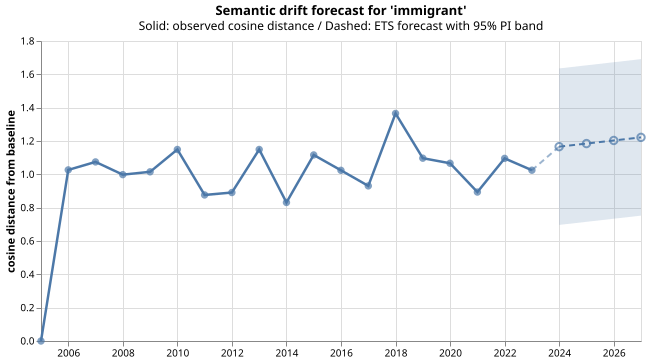

In [41]:
from pycorpdiff.viz import semantic_forecast_plot

sem_fc = pcd.forecast_semantic_drift(sem_traj, horizon=4, level=0.95)
print(sem_fc)

semantic_forecast_plot(sem_traj, sem_fc).properties(
    width=600, height=300,
    title=alt.TitleParams(
        text="Semantic drift forecast for 'immigrant'",
        subtitle='Solid: observed cosine distance / Dashed: ETS forecast with 95% PI band',
    ),
)

**Neighbourhood drift** — `neighborhood_drift` returns the top-k contextual neighbours of a target in each corpus and partitions them into `shared` / `gained_in_a` / `lost_in_a`. With SBERT this surfaces words that have *become* semantically close to the target in one frame but not the other.

In [42]:
drift = pcd.neighborhood_drift(
    human, criminal, 'immigrant',
    k=8, embedder=pcd.HashEmbedder(dim=64), window=4, min_count=2,
)
drift

,neighbor,sim_a,sim_b,rank_a,rank_b,drift,status
0,consider,-0.168328,0.223606,NaN,2.0,-0.391934,lost_in_a
1,immigration,0.150328,-0.136726,4.0,NaN,0.287053,gained_in_a
2,daily,NaN,0.265157,NaN,1.0,-0.265157,lost_in_a
3,richness,0.257053,NaN,1.0,NaN,0.257053,gained_in_a
4,question,0.205543,NaN,2.0,NaN,0.205543,gained_in_a
5,alarms,NaN,0.184464,NaN,3.0,-0.184464,lost_in_a
6,threat,NaN,0.171479,NaN,4.0,-0.171479,lost_in_a
7,has,-0.014515,0.143764,NaN,6.0,-0.158279,lost_in_a
8,community,0.149889,NaN,5.0,NaN,0.149889,gained_in_a
9,gangs,NaN,0.144774,NaN,5.0,-0.144774,lost_in_a


---

## Part VI — The fanout

The same three verbs answer questions at every grain. Same corpus, different slices.

### Cross-party within a topic — Labour vs Conservative on the NHS

In [43]:
nhs = corpus.slice(topic='nhs')
lab_v_con = pcd.compare(
    nhs.slice(party='Labour'),
    nhs.slice(party='Conservative'),
).keyness(min_count=2)
lab_v_con.table.head(8)

,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,p_adjusted
0,commend,4,0,2.014599,1.985401,5.486995,0.019158,3.148863,inf,0.593801,0.543034
1,motion,4,0,2.014599,1.985401,5.486995,0.019158,3.148863,inf,0.593801,0.543034
2,move,0,3,1.510949,1.489051,-4.202839,0.040356,-2.828417,-100.0,0.312457,0.543034
3,workforce,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
4,supported,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
5,training,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
6,programmes,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
7,proper,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034


### Cross-topic — climate discourse vs NHS discourse

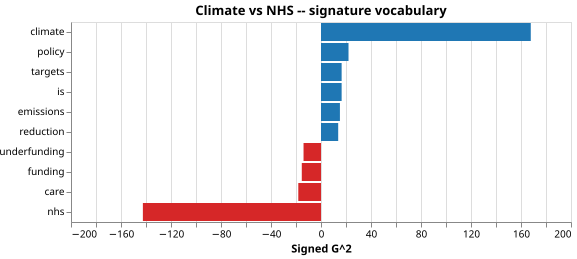

In [44]:
climate_v_nhs = pcd.compare(
    corpus.slice(topic='climate'),
    corpus.slice(topic='nhs'),
).keyness(min_count=3)
climate_v_nhs.plot(kind='bar', n=10).properties(
    width=500, title='Climate vs NHS -- signature vocabulary'
)

### Before/after the Brexit referendum — across the full corpus, not just one topic

In [45]:
ba = pcd.compare.before_after(
    corpus, event_date='2016-06-23', time_col='date'
).keyness(min_count=5)
ba.table.head(8)

,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,p_adjusted
0,criminal,0,18,10.572009,7.427991,-31.864187,1.653376e-08,-5.718659,-100.0,112818.671125,0.000003
1,european,23,0,13.508678,9.491322,24.479448,7.510671e-07,5.045383,inf,2810.640910,0.000069
2,gangs,0,12,7.048006,4.951994,-21.242791,4.046293e-06,-5.153062,-100.0,557.152663,0.000250
3,family,17,0,9.984675,7.015325,18.093505,2.103176e-05,4.620077,inf,115.375991,0.000956
4,invasion,0,10,5.873338,4.126662,-17.702326,2.583105e-05,-4.901523,-100.0,94.879405,0.000956
5,demand,15,0,8.810007,6.189993,15.964858,6.452930e-05,4.444991,inf,39.800220,0.001735
6,threat,0,9,5.286004,3.713996,-15.932094,6.565595e-05,-4.757133,-100.0,39.153521,0.001735
7,union,14,0,8.222674,5.777326,14.900534,1.133309e-04,4.348775,inf,23.376015,0.002330


### Beyond pairwise — N-way keyness across all four parties

Pairwise keyness asks "is this term distinctive in A vs B". When you have three or more corpora — three news outlets, five parties, ten decades — the natural extension is *one-way* keyness: for each term, does its rate vary across the panel of corpora more than chance explains?

`pcd.keyness_multi([a, b, c, ...])` does exactly that, with a χ²(df=N−1) reference distribution. For N=2 it reduces *exactly* to the pairwise G² we already trust (verified by a unit test).

In [46]:
PARTIES = ['Conservative', 'Labour', 'Liberal Democrat', 'SNP']
nhs_by_party = [nhs.slice(party=p) for p in PARTIES]
nway = pcd.keyness_multi(nhs_by_party, labels=PARTIES, min_count=3)
print(f'{len(nway):,} terms ranked across {len(PARTIES)} parties')
df_to_sofra(
    nway.head(12).reset_index(),
    caption='N-way keyness — top 12 terms across four parties (NHS speeches)',
    footnotes=('χ²(df = 3) test of equal rate across the four parties.',),
)

120 terms ranked across 4 parties


term,count_Conservative,count_Labour,count_Liberal Democrat,count_SNP,g2,p_value,p_adjusted
rise,4,3,0,0,+10.01,0.018,0.627
we,3,2,0,0,+7.26,0.064,0.627
constituents,3,2,0,0,+7.26,0.064,0.627
much,3,2,0,0,+7.26,0.064,0.627
owe,3,2,0,0,+7.26,0.064,0.627
accident,0,0,4,1,+7.19,0.066,0.627
crises,0,0,4,1,+7.19,0.066,0.627
creates,0,0,4,1,+7.19,0.066,0.627
in,0,0,4,1,+7.19,0.066,0.627
departments,0,0,4,1,+7.19,0.066,0.627


A heatmap is the natural visualisation for an N-way table: rows are the top-distinguishing terms; columns are corpora; cell colour encodes *rate per 1000 tokens* so the visual axis is comparable across corpus-size differences.

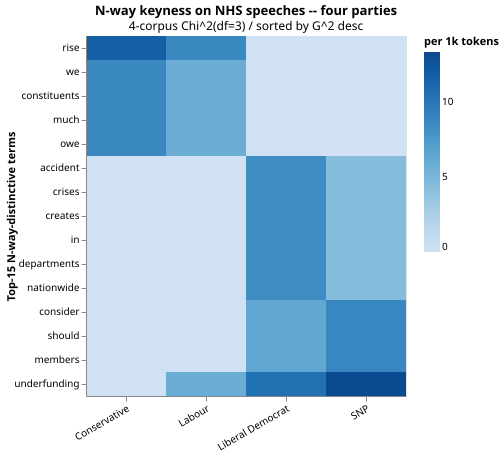

In [47]:
top_n = 15
totals_by_party = pd.Series(
    {p: nhs.slice(party=p).total_tokens() for p in PARTIES}
)

nway_long = (
    nway.head(top_n)
    .reset_index()
    .melt(
        id_vars=['term', 'g2'],
        value_vars=[f'count_{p}' for p in PARTIES],
        var_name='party_col',
        value_name='count',
    )
    .assign(
        party=lambda d: d['party_col'].str.replace('count_', '', regex=False),
        rate_per_1k=lambda d: 1000 * d['count'] / d['party'].map(totals_by_party),
    )
)

(
    alt.Chart(nway_long)
    .mark_rect()
    .encode(
        x=alt.X('party:N', title=None, axis=alt.Axis(labelAngle=-30)),
        y=alt.Y('term:N', sort=alt.SortField('g2', order='descending'),
                title='Top-15 N-way-distinctive terms'),
        color=alt.Color('rate_per_1k:Q', scale=alt.Scale(scheme='blues'),
                        title='per 1k tokens'),
        tooltip=['term', 'party', 'count', 'rate_per_1k:Q', 'g2'],
    )
    .properties(
        width=320, height=360,
        title=alt.TitleParams(
            text='N-way keyness on NHS speeches -- four parties',
            subtitle=f'{len(PARTIES)}-corpus Chi^2(df={len(PARTIES)-1}) / sorted by G^2 desc',
        ),
    )
)

---

## Part VII — Cross-validation receipts

**The math agrees with the standard tools.** pycorpdiff cross-validates against three open-source reference implementations and a fourth diachronic-embeddings dataset:

- **Rayson's LL Wizard** — hand-computed reference triples spanning Hardie's BNC examples, equal-rate / specialised-vocabulary / lopsided over-rep, and the textbook 174-vs-29-per-million case
- **NLTK (`BigramAssocMeasures`)** — PMI and t-score agreement to ≤ 1e-12 on every adjacent bigram; MI³ via the `mi_like(power=3)` identity
- **Scattertext (Kessler 2017)** — behavioural agreement on the 2012 US Conventions corpus
- **HistWords (Hamilton et al. 2016)** — known-shifter / stable-word sanity check on Stanford SNAP COHA decade embeddings (slow tier; skips gracefully when the archive is unreachable)

Below we show the Rayson and Scattertext checks live; the slow-tier ones live in the test suite.

### Rayson's LL Wizard — the canonical worked example

From the Lancaster CASS reference: 12000 occurrences per million in one corpus vs 10000 per million in another. Rayson's wizard reports G² ≈ 182.07. Our `log_likelihood` agrees.

In [48]:
from pycorpdiff.keyness import log_likelihood

ref = log_likelihood(
    pd.Series({'the': 12000}),
    pd.Series({'the': 10000}),
    total_a=1_000_000, total_b=1_000_000,
)
print(f"pycorpdiff G²: {ref.loc['the', 'g2']:.4f}")
print(f"Rayson's LL Wizard: 182.0694")
print(f"agreement: {'✓' if abs(ref.loc['the', 'g2'] - 182.0694) < 0.01 else '✗'}")

df_to_sofra(
    pd.DataFrame([
        {'case': 'classic_12k_vs_10k', 'rayson_LL_wizard': 182.0694,
         'pycorpdiff_G2': round(float(ref.loc['the', 'g2']), 4),
         'abs_diff': round(abs(float(ref.loc['the', 'g2']) - 182.0694), 6)},
    ]),
    caption="Rayson's LL Wizard — canonical worked example agreement",
    footnotes=('Rounded to 4 decimal places (precision of the published wizard).',),
)


pycorpdiff G²: 182.0695
Rayson's LL Wizard: 182.0694
agreement: ✓


SofraTable(rows=1, cols=4, theme='jama')

### Scattertext on the 2012 US Presidential Conventions

Scattertext bundles the Democratic and Republican convention speeches from 2012 as a known fixture. We can plug them straight into pycorpdiff and compare top-N keyness terms to Scattertext's scaled F-score — different measures, but they should surface a substantial common subset on real political-discourse data.

*(Skip the next two cells if `scattertext` isn't installed — `pip install scattertext`.)*

In [49]:
try:
    import scattertext as st
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        conv_df = st.SampleCorpora.ConventionData2012.get_data()
    conv_corpus = pcd.from_dataframe(conv_df, text_col='text', meta_cols=('party', 'speaker'))
    conv_keyness = pcd.compare(
        conv_corpus.slice(party='democrat'),
        conv_corpus.slice(party='republican'),
    ).keyness(min_count=10)
    print(f'{len(conv_corpus)} speeches from the 2012 US conventions')
    print(f'{len(conv_keyness.table)} shared-vocabulary terms')
    print('Top 10 Dem-leaning terms by pycorpdiff signed G²:')
    conv_top10 = (
        conv_keyness.table[conv_keyness.table['g2'] > 0]
        .head(10)[['term', 'count_a', 'count_b', 'g2', 'log_ratio']]
    )
except ImportError:
    print('scattertext not installed — skipping this cell. `pip install scattertext` to run.')
    conv_keyness = None
    conv_top10 = None

conv_top10

189 speeches from the 2012 US conventions
1333 shared-vocabulary terms
Top 10 Dem-leaning terms by pycorpdiff signed G²:


,term,count_a,count_b,g2,log_ratio
0,obama,537,167,115.098190,1.280085
2,president,740,301,88.862683,0.894323
3,class,161,25,76.730612,2.260946
4,middle,168,28,75.728594,2.161696
5,barack,202,46,67.243674,1.720601
7,forward,106,16,51.600194,2.288297
10,for,1020,542,45.676014,0.509563
11,auto,37,0,41.698498,5.826800
13,health,115,25,40.329304,1.777305
14,education,107,22,39.801841,1.854321


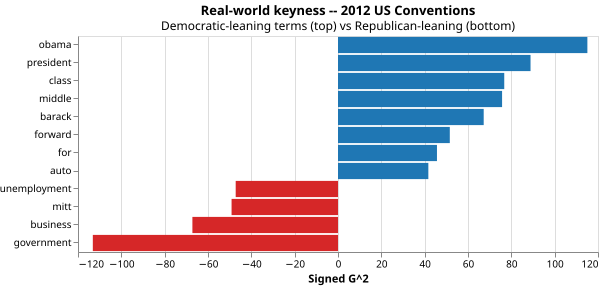

In [50]:
if conv_keyness is not None:
    display(conv_keyness.plot(kind='bar', n=12).properties(
        width=520,
        title=alt.TitleParams(
            text='Real-world keyness -- 2012 US Conventions',
            subtitle='Democratic-leaning terms (top) vs Republican-leaning (bottom)',
        ),
    ))

### HistWords reference values for famous semantic shifters

Hamilton, Leskovec & Jurafsky (2016) computed aligned diachronic word2vec embeddings on COHA and reported specific cosine distances for famous shifters. We ship those reference values for users to validate their own semantic-shift pipelines against.

In [51]:
from pycorpdiff.datasets.histwords import HAMILTON_REFERENCE_SHIFTS_COHA_1900_1990

ref_df = pd.DataFrame(
    sorted(HAMILTON_REFERENCE_SHIFTS_COHA_1900_1990.items(), key=lambda x: -x[1]),
    columns=['word', 'cosine_distance_1900_to_1990'],
)
ref_df['interpretation'] = ref_df['word'].map({
    'gay': 'shift: happy/carefree → homosexual',
    'broadcast': 'shift: scattering seeds → transmitting radio/TV',
    'awful': 'shift: awe-inspiring → very bad',
    'terrific': 'shift: terrifying → great',
    'guy': 'shift: Guy Fawkes effigy → generic male',
    'the': 'stable function word',
    'and': 'stable function word',
    'of': 'stable function word',
    'is': 'stable function word',
})
df_to_sofra(
    ref_df,
    caption='Hamilton et al. (2016) HistWords reference cosine displacements, 1900s→1990s',
    footnotes=('COHA eng-fiction word2vec; cosine distance between aligned decade centroids.',),
)


SofraTable(rows=9, cols=3, theme='jama')

---

## Part VIII — The plumbing

Beyond the analytical surface, pycorpdiff plays nicely with the surrounding PyData stack.

### polars round-trip

`Corpus` accepts either pandas or polars frames at construction and round-trips back out. The analytical layer is pandas-internal; polars users get ergonomic interop without us doubling the math surface.

In [52]:
try:
    import polars as pl
    pl_df = pl.DataFrame({
        'text': ['the migrant worker arrived', 'the migrant criminal threat'],
        'frame': ['humanising', 'criminalising'],
    })
    polars_corpus = pcd.from_dataframe(pl_df, text_col='text', meta_cols=('frame',))
    print(f'pandas-internal: {type(polars_corpus.docs).__name__}')
    print(f'polars round-trip: {type(polars_corpus.to_polars()).__name__}')
    print(polars_corpus.to_polars())
except ImportError:
    print('polars not installed — skipping this cell. `pip install pycorpdiff[polars]` to run.')

pandas-internal: DataFrame
polars round-trip: DataFrame
shape: (2, 2)
┌─────────────────────────────┬───────────────┐
│ text                        ┆ frame         │
│ ---                         ┆ ---           │
│ str                         ┆ str           │
╞═════════════════════════════╪═══════════════╡
│ the migrant worker arrived  ┆ humanising    │
│ the migrant criminal threat ┆ criminalising │
└─────────────────────────────┴───────────────┘


### DuckDB → Corpus

Filter large parquet collections in DuckDB before they ever touch pandas. `read_duckdb` runs any SQL query and wraps the result.

In [53]:
try:
    import duckdb
    con = duckdb.connect()
    # Materialise our Hansard sample as an in-memory DuckDB table,
    # then query it back through SQL.
    con.register('hansard', corpus.docs)
    post_2020_immigration = pcd.read_duckdb(
        con,
        "SELECT text, party, date FROM hansard "
        "WHERE topic = 'immigration' AND year >= 2020",
        text_col='text', meta_cols=('party', 'date'),
    )
    print(f'DuckDB-filtered subset: {len(post_2020_immigration)} immigration speeches from 2020+')
    print(post_2020_immigration.docs[['party', 'date']].value_counts().head(5))
except ImportError:
    print('duckdb not installed — skipping this cell. `pip install pycorpdiff[duckdb]` to run.')

DuckDB-filtered subset: 11 immigration speeches from 2020+
party         date      
Conservative  2020-10-10    1
              2020-10-27    1
              2022-11-21    1
Labour        2020-05-23    1
              2021-04-26    1
Name: count, dtype: int64


### Pluggable tokenizers — multilingual is one adapter away

Any callable matching `__call__(text: str) -> list[str]` satisfies the `Tokenizer` Protocol. spaCy / Stanza / jieba / fugashi adapters are one-line wrappers; the default `RegexTokenizer` is Unicode-native out of the box.

In [54]:
# Default Unicode-aware tokenizer handles non-Latin scripts directly.
default = pcd.RegexTokenizer()
print('Greek:    ', default('Η μετανάστευση είναι ένα παγκόσμιο φαινόμενο'))
print('Cyrillic: ', default('Миграция — это глобальное явление'))
print('English:  ', default('Migration is a global phenomenon'))

Greek:     ['η', 'μετανάστευση', 'είναι', 'ένα', 'παγκόσμιο', 'φαινόμενο']
Cyrillic:  ['миграция', 'это', 'глобальное', 'явление']
English:   ['migration', 'is', 'a', 'global', 'phenomenon']


In [55]:
# A custom tokenizer is literally a one-line adapter.
class StemTokenizer:
    """Toy lemmatiser-like tokenizer for the showcase."""
    def __call__(self, text: str) -> list[str]:
        crude_stems = {'arrived': 'arrive', 'settled': 'settle', 'thrived': 'thrive'}
        return [crude_stems.get(t, t) for t in default(text)]

tokenized = pcd.from_dataframe(
    pd.DataFrame({'text': ['the migrant worker arrived and settled and thrived']}),
    text_col='text',
    tokenizer=StemTokenizer(),
)
tokenized.tokens()[0]

['the', 'migrant', 'worker', 'arrive', 'and', 'settle', 'and', 'thrive']

### Sparse doc-term matrices — escape hatch for big corpora

The default dense `n_docs × |vocab|` matrix is fine for medium millions of tokens but breaks down at ~100K docs. `doc_term_counts_sparse()` returns the canonical scikit-learn shape — `(csr_matrix, vocab)` — so a pycorpdiff Corpus drops straight into anything that consumes `CountVectorizer` output.

In [56]:
matrix, vocab = corpus.doc_term_counts_sparse(min_count=3)
print(f'sparse DTM: {matrix.shape[0]:,} docs × {matrix.shape[1]:,} terms')
print(f'non-zeros: {matrix.nnz:,} '
      f'({100 * matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.2f}% density)')
print(f'memory footprint: ~{matrix.data.nbytes / 1024:.1f} KB '
      f'(dense would be ~{matrix.shape[0] * matrix.shape[1] * 8 / 1024:.1f} KB)')

sparse DTM: 193 docs × 269 terms
non-zeros: 4,420 (8.51% density)
memory footprint: ~34.5 KB (dense would be ~405.6 KB)


### HuggingFace Datasets — one line to a Corpus

Public text corpora — IMDb, OpenWebText, AG News, every Hansard mirror — live on the 🤗 Hub. `pcd.from_huggingface(dataset_id, ...)` wraps `datasets.load_dataset` and converts the result to a `Corpus` in one call.

```python
corpus = pcd.from_huggingface(
    'stanfordnlp/imdb', split='train[:1000]',
    text_col='text', meta_cols=('label',),
)
pos = corpus.slice(label=1); neg = corpus.slice(label=0)
pcd.compare(pos, neg).keyness().plot(kind='scattertext')
```

`pip install 'pycorpdiff[huggingface]'` first. Skipped here to keep the notebook offline-runnable in CI.

### Results go anywhere — HTML, JSON, parquet

Every Result has `.to_html(path)` and `.to_json(path)` next to `.to_df()`. Drop the HTML into a static-site build; ship the JSON to a JavaScript dashboard; or `.to_df().to_parquet()` for downstream pipelines. The numbers you analysed are the numbers you publish.

In [57]:
# HTML — paste into a blog post or paper draft
html_snippet = keyness.to_html().splitlines()[:6]
print('\n'.join(html_snippet) + '\n...')

# JSON — orient='records' by default, one dict per term
json_snippet = keyness.to_json()
print(f'\nJSON: {len(json_snippet):,} bytes, {json_snippet.count(chr(125))} records')

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>term</th>
      <th>count_a</th>
...

JSON: 37,496 bytes, 119 records


### Content-derived hashing — memoise analyses across runs

`Corpus.__hash__` is content-derived via `pandas.util.hash_pandas_object`, so two corpora with identical docs + schema + tokenizer hash the same — and different ones don't. Drop a Corpus into a `functools.lru_cache` key, a `joblib.Memory` cache, or your own disk-backed manifest, and avoid recomputing the expensive keyness/semantic-shift passes.

In [58]:
h1 = hash(corpus)
h2 = hash(pcd.load_hansard_sample())  # rebuilt from disk
h3 = hash(corpus.with_tokenizer(pcd.RegexTokenizer(lowercase=False)))
print(f'same-config hash matches: {h1 == h2}')
print(f'different-tokenizer hash diverges: {h1 != h3}')

same-config hash matches: True
different-tokenizer hash diverges: True


---

## Part IX — Where next

We've now driven every analytical surface in pycorpdiff through one coherent research question. To take this to your own data:

**Real corpora.** The Hansard sample is synthetic but real-shaped. For actual research:

```python
corpus = pcd.fetch_hansard(
    'immigration', start_date='2020-01-01', end_date='2024-12-31',
    cache_dir='~/.cache/hansard',
)
```

Hits parliament.uk's public Hansard search API. No auth. UK Open Government Licence. The same shape as `load_hansard_sample()` so every cell above works.

**Real embeddings.** Swap `HashEmbedder` for `SBERTEmbedder` everywhere semantic shift / trajectory / neighbourhood drift appears:

```python
embedder = pcd.SBERTEmbedder()                                   # English default
embedder = pcd.SBERTEmbedder('paraphrase-multilingual-MiniLM-L12-v2')  # 50+ languages
```

Add `pip install 'pycorpdiff[semantic]'` first.

**Reproducibility.** Every Result has `.to_df()` → parquet round-trip; most Results also implement `.to_html()` and `.to_json()` for static-site or dashboard handoff (see `docs/design.md` for the per-Result method matrix). Wrap an analytical run in a single script that writes its outputs to JSON; re-running the script regenerates them deterministically.

**Cross-validation.** Wire your own pipeline up to `pcd.histwords_cosine_shift(1900, 1990, target, source='coha')` for diachronic-embedding validation, or compare `pcd.compare(a, b).keyness(formula='dunning')` against `quanteda::textstat_keyness(measure='lr')` informally — note that token-level conventions differ between regex tokenisation and quanteda's `remove_punct=TRUE`, so cross-runtime parity holds only up to tokenisation, not byte-for-byte.

---

**Cheat sheet — every analytical surface in one block:**

```python
import pycorpdiff as pcd

# Load
corpus = pcd.from_dataframe(df, text_col='text', meta_cols=(...))

# Slice
a = corpus.slice(outlet='Guardian')
b = corpus.slice(outlet='Mail')

# Compare — three verbs
k = pcd.compare(a, b).keyness()                       # default formula='rayson'
k_d = pcd.compare(a, b).keyness(formula='dunning')    # full 4-cell G²
c = pcd.compare(a, b).collocation_shift('migrant')
s = pcd.compare(a, b).semantic_shift('migrant', embedder=pcd.SBERTEmbedder())

# Track
tr = pcd.track(corpus, 'migrant').over_time(freq='Y')
tr.changepoints()
tr.interrupted_time_series(event_date='2016')

# Before/after
ba = pcd.compare.before_after(corpus, event_date='2016-06-23').keyness()

# Result methods — each Result implements the relevant subset of:
# .to_df() · .plot() · .to_html() · .to_json() · .summary() · .explain()
```

Read the [README](../README.md) for the design philosophy, [`docs/design.md`](../docs/design.md) for the three-layer architecture, and [`docs/statistical-methods.md`](../docs/statistical-methods.md) for every metric's reference.